# ベクトル解析

機械学習アルゴリズムの多くは、目的関数と呼ばれる関数の最小化に基づいている。例えば:

> - 線形回帰(≒曲線のフィッティング)では、尤度が最大となるように重みパラメータを調整する。
> - ニューラルネットワークでは、損失関数が最小となるように重みやバイアスと呼ばれるパラメータを調整する。
> - クラスタリングでは、クラスタの中心がデータ点から最も近いように調整する。
> - オートエンコーダでは、入力データと復元されたデータの差が最小となるようにパラメータを調整する。
> - 混合ガウスモデル(GMM)では、各ガウス分布の平均・分散を調整して尤度が最大となるようにする。

これらの問題は、勾配に基づく最適化アルゴリズムを用いて解くことが多い。

こうした目的関数を最小化するためには、一般に多変数の関数の微分を計算する必要がある。

$$
\begin{align}
f: \mathbb{R}^D &\to \mathbb{R} \\
\mathbf{x} &\mapsto f(\mathbf{x}) = f(x_1, x_2, \ldots, x_D)
\end{align}
$$

上で関数$f$は$D$次元の実数値ベクトル$\mathbf{x}$を入力として受け取り、実数値を出力する関数である。


$N$個のデータ点を持つデータセット $\{(x_i, y_i)\}_{i=1}^N$ が与えられた際、直線$f(x)=ax+b$で近似する線形回帰を考えるとする。この際、最小化すべき目的関数は次のように定義される。

$$
\begin{align}
f(a, b) &= \frac{1}{N} \sum_{i=1}^N (y_i - (ax_i + b))^2 
\end{align}
$$

ここで、$y_i$は$i$番目のデータ点の出力値、$x_i$は$i$番目のデータ点の入力値である。
データ点が固定されているとき、傾きと切片のパラメータ$(a, b)$を調整して
目的関数$f(a, b)$を最小化することが目的となる。
これはまさに上の多変数関数の定義の特殊な場合になっている。

## 一変数の微分

関数$f$が一変数のとき、微分は次のように定義される。

$$
\begin{align}
\frac{df}{dx} &= \lim_{h \to 0} \frac{f(x + h) - f(x)}{h}
\end{align}
$$

### テイラー展開

`````{admonition} 定義: テイラー級数
:class: note
関数$f$が点$x_0$の近傍で無限回連続微分可能（$f \in C^\infty$）であるとき、$f$のテイラー級数は次のように定義される。

$$
\begin{align}
T_\infty(x) &= \sum_{n=0}^\infty \frac{f^{(n)}(x_0)}{n!} (x - x_0)^n
\end{align}
$$ (TaylorSeries)

特に$x_0 = 0$のとき、テイラー級数はマクローリン級数と呼ばれる。

また、$x_0$のある近傍で級数が収束して$f(x) = T_\infty(x)$が成り立つとき、$f$は$x_0$でテイラー展開可能であるという。無限回微分可能であるだけでは、この一致は保証されない。
`````


`````{admonition} 問題
:class: attention

多項式関数$f(x) = x^3$があるとき、$x_0 = 1$におけるテイラー多項式

$$
T_k(x) \equiv \sum_{n=0}^k \frac{f^{(n)}(x_0)}{n!} (x - x_0)^n
$$

の次数$k$に応じた展開を求め、テイラー級数がもとの関数$f$と一致することを確認せよ。4階以上の導関数$f^{(n)}(x)$（$n\geq4$）が0であることは用いて良い。
`````

### 微分の基本的性質


- 線形性: $\frac{d}{dx}(af(x) + bg(x)) = a\frac{df}{dx} + b\frac{dg}{dx}$
- 積の微分: $\frac{d}{dx}(f(x)g(x)) = f(x)\frac{dg}{dx} + g(x)\frac{df}{dx}$
- 商の微分: $\frac{d}{dx}\left(\frac{f(x)}{g(x)}\right) = \frac{g(x)\frac{df}{dx} - f(x)\frac{dg}{dx}}{g(x)^2}$（$g(x)\ne0$）
- 合成関数の微分: $\frac{d}{dx}f(g(x)) = f'(g(x))\frac{dg}{dx}$

特に合成関数の微分は連鎖律(チェインルール)とも呼ばれ、ニューラルネットワークの逆伝播アルゴリズムにおいて重要な役割を果たす。

`````{admonition} 問題
:class: attention

以下の関数$f,g$で定義される合成関数$h(x) = f(g(x))$の微分を求めて、連鎖律を確認せよ。

$$
\begin{align}
f(x) &= x^2 + 3x + 1 \\
g(x) &= \exp(x)
\end{align}
$$
`````


## 偏微分: 多変数への拡張

ここまでの議論を、多変数関数に拡張しよう。


`````{admonition} 定義: 偏微分
:class: note

$n$個の変数$x_1, x_2, \ldots, x_n$を持つ関数$f(\mathbf{x})$の偏微分は、次のように定義される。

$$
\begin{align}
\frac{\partial f}{\partial x_i} &= \lim_{h \to 0} \frac{f(x_1, \ldots, x_i + h, \ldots, x_n) - f(x_1, \ldots, x_i, \ldots, x_n)}{h}
\end{align}
$$

本講義ノートでは、変数ベクトル$\mathbf{x} = (x_1, \ldots, x_n)^T$と同じ向きに、これらの偏微分をまとめた**列ベクトル**を勾配(gradient)と呼ぶ。

$$
\begin{align}
\nabla_{\mathbf{x}} f \equiv \mathrm{grad} f &= \begin{bmatrix}
\frac{\partial f}{\partial x_1} \\
\frac{\partial f}{\partial x_2} \\
\vdots \\
\frac{\partial f}{\partial x_n}
\end{bmatrix} \in \mathbb{R}^{n \times 1}
\end{align}
$$

スカラー関数の$\frac{\partial f}{\partial \mathbf{x}}$も、この列ベクトル$\nabla_{\mathbf{x}} f$を表すものとする。文献によっては行ベクトルで表す規約もあるため、転置の有無に注意する。

`````


### 全微分と一次近似

勾配は、入力を少し変えたときの関数値の変化を表す。
点$\mathbf{x}$の近傍で定義された関数$f$について、

$$
f(\mathbf{x}+\Delta\mathbf{x})
=f(\mathbf{x})+\nabla f(\mathbf{x})^T\Delta\mathbf{x}
+o(\|\Delta\mathbf{x}\|)
$$

と書けるとき、$f$は$\mathbf{x}$で**全微分可能**であるという。
ここで$\|\cdot\|$はユークリッドノルムであり、$o(\|\Delta\mathbf{x}\|)$は、
$\Delta\mathbf{x}\to\mathbf0$のときに$\|\Delta\mathbf{x}\|$で割った値が0に近づく誤差を表す。
一次の項

$$
df=\nabla f(\mathbf{x})^T d\mathbf{x}
=\sum_{i=1}^n\frac{\partial f}{\partial x_i}dx_i
$$

を**全微分**と呼ぶ。つまり、十分小さな変位なら、各変数による一次の変化を足すことで関数値の変化を近似できる。

偏微分は座標軸に沿った変化を調べるのに対して、全微分可能性は任意の方向からの変位を一つの線形写像で近似できることを要求する。
したがって、すべての偏微分が存在するだけでは全微分可能とは限らない。
十分条件として、すべての偏導関数がその点の近傍で存在し、連続ならば全微分可能である。
以後、この章で多変数関数を「微分可能」と呼ぶときは全微分可能を意味する。

### 方向微分と勾配の向き

微分可能な$f$に対して、単位ベクトル$\mathbf{v}$（$\|\mathbf{v}\|=1$）の方向に進んだときの変化率を**方向微分**と呼ぶ。

$$
D_{\mathbf{v}}f(\mathbf{x})
=\left.\frac{d}{dt}f(\mathbf{x}+t\mathbf{v})\right|_{t=0}
=\nabla f(\mathbf{x})^T\mathbf{v}.
$$

$\nabla f(\mathbf{x})\ne\mathbf0$のとき、勾配と$\mathbf{v}$のなす角を$\theta$とすると、
この内積は$\|\nabla f(\mathbf{x})\|\cos\theta$となる。
したがって、単位長さあたりの増加率が最大となるのは勾配の向き、最小となるのは負の勾配の向きである。
これはユークリッドノルムで移動距離を測った場合の性質である。

例えば、$\Delta\mathbf{x}=-\eta\nabla f(\mathbf{x})$とおくと、勾配がゼロでない点では

$$
f(\mathbf{x}-\eta\nabla f(\mathbf{x}))-f(\mathbf{x})
=-\eta\|\nabla f(\mathbf{x})\|^2+o(\eta)<0
$$

が十分小さな$\eta>0$について成り立つ。これが勾配降下法の根拠である。
移動幅$\eta$が大きすぎると、この減少は保証されない。
具体的な更新方法は[最適化の章](Chapter_Optimization.ipynb)で扱う。

また、等高線$f(\mathbf{x})=c$に沿う滑らかな曲線$\mathbf{x}(t)$を考えると、関数値が変わらないため、

$$
0=\frac{d}{dt}f(\mathbf{x}(t))
=\nabla f(\mathbf{x}(t))^T\frac{d\mathbf{x}}{dt}
$$

となる。勾配がゼロでない点では、勾配は等高線の接線に直交する。
次の図では$f(x,y)=x^2+2y^2$の値を背景の色で表し、半透明のグレーの等高線と、勾配$(2x,4y)^T$を重ねる。
赤い矢印は勾配の向きを表し、長さは見やすいように揃えている。
白い点と矢印は、点$(2,1.25)$を出発点として、移動幅$\eta=0.15$で勾配降下法を5ステップ適用した経路を表す。白い丸が出発点、小さな白い点が途中の各ステップ、白い×印が5ステップ後の位置である。

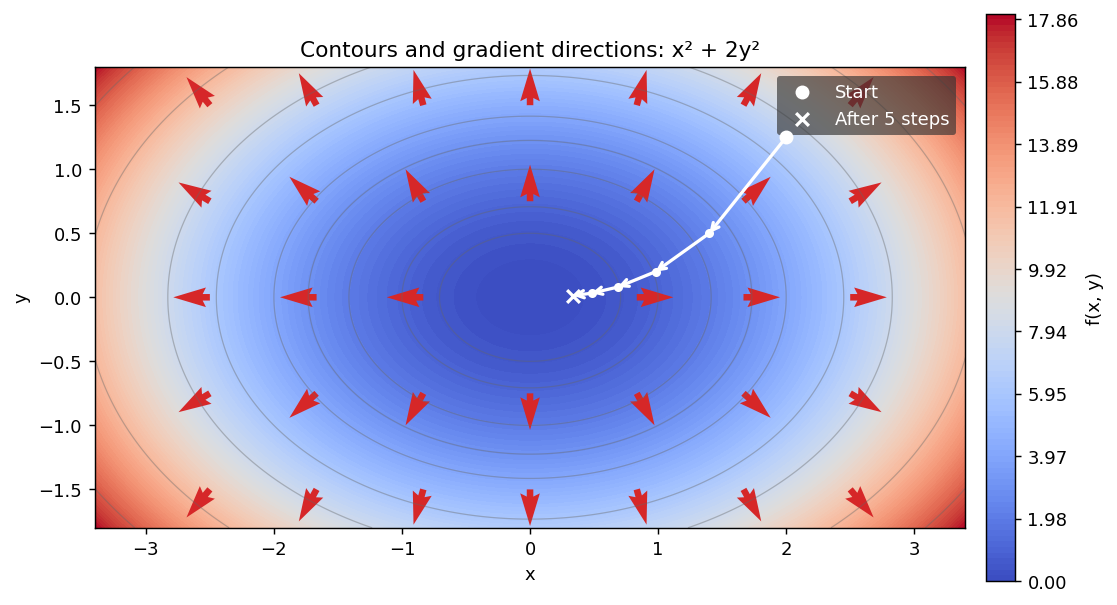

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x_values = np.linspace(-3.4, 3.4, 361)
y_values = np.linspace(-1.8, 1.8, 241)
gx, gy = np.meshgrid(x_values, y_values)
fig, ax = plt.subplots(figsize=(9, 4.8))
values = gx**2 + 2 * gy**2
contours = ax.contourf(gx, gy, values,
                       levels=np.linspace(0, values.max(), 101),
                       cmap="coolwarm", antialiased=False)
ax.contour(gx, gy, values, levels=[0.5, 1, 2, 3, 4, 6, 8, 12, 16],
           colors="0.4", alpha=0.4, linewidths=0.7)
fig.colorbar(contours, ax=ax, label="f(x, y)", pad=0.02)

qx, qy = np.meshgrid(np.linspace(-2.5, 2.5, 7), np.linspace(-1.5, 1.5, 5))
grad_x, grad_y = 2 * qx, 4 * qy
grad_norm = np.hypot(grad_x, grad_y)
nonzero = grad_norm > 0
ax.quiver(qx[nonzero], qy[nonzero],
          grad_x[nonzero] / grad_norm[nonzero],
          grad_y[nonzero] / grad_norm[nonzero],
          angles="xy", scale_units="xy", scale=3.5, color="tab:red")

# 移動の各段階が見えるように、原点から少し離れた点を出発点とする。
point = np.array([2.0, 1.25])
eta = 0.15
n_steps = 5
trajectory = [point.copy()]
for _ in range(n_steps):
    current = trajectory[-1]
    gradient = np.array([2 * current[0], 4 * current[1]])
    trajectory.append(current - eta * gradient)
trajectory = np.array(trajectory)

for current, following in zip(trajectory[:-1], trajectory[1:]):
    ax.annotate("", xy=following, xytext=current,
                arrowprops={"arrowstyle": "->", "color": "white", "lw": 1.8,
                            "shrinkA": 0, "shrinkB": 0}, zorder=5)
ax.scatter(*trajectory[0], color="white", s=45, label="Start", zorder=6)
ax.scatter(trajectory[1:-1, 0], trajectory[1:-1, 1], color="white", s=16, zorder=6)
ax.scatter(*trajectory[-1], color="white", marker="x", s=50, linewidths=1.8,
           label=f"After {n_steps} steps", zorder=6)
ax.set(xlabel="x", ylabel="y", title="Contours and gradient directions: x² + 2y²",
       xlim=(-3.4, 3.4), ylim=(-1.8, 1.8), aspect="equal")
ax.legend(loc="upper right", facecolor="0.2", edgecolor="none",
          framealpha=0.65, labelcolor="white")
fig.tight_layout()
plt.show()

### 多変数関数の連鎖律

多変数の場合のチェインルールを整理しておこう。

微分可能な二変数関数$f: \mathbb{R}^2 \to \mathbb{R}$と、$t$に依存する変数$\mathbf{x}(t) = (x_1(t), x_2(t))^T$に対して、合成関数の微分は勾配と$\frac{d\mathbf{x}}{dt}$の内積で表される。

$$
\begin{align}
\frac{d}{dt} f(\mathbf{x}(t))
&= \bigl(\nabla_{\mathbf{x}} f(\mathbf{x}(t))\bigr)^T \frac{d\mathbf{x}}{dt} \\
&= \begin{bmatrix}
\frac{\partial f}{\partial x_1} & \frac{\partial f}{\partial x_2}
\end{bmatrix}
\begin{bmatrix}
\frac{d x_1}{dt} \\
\frac{d x_2}{dt}
\end{bmatrix}
= \frac{\partial f}{\partial x_1} \frac{d x_1}{dt}
+ \frac{\partial f}{\partial x_2} \frac{d x_2}{dt}
\end{align}
$$

ここで、$f$の偏微分は$\mathbf{x}(t)$で評価する。勾配そのものは列ベクトルであり、内積を取るために転置している。

あるいは、$\mathbf{x}$が$\mathbf{u} = (s,t)^T$に依存するとき、次節で定義するヤコビ行列を用いて

$$
\mathbf{J}_{\mathbf{x}} = \frac{d\mathbf{x}}{d\mathbf{u}}
= \begin{bmatrix}
\frac{\partial x_1}{\partial s} & \frac{\partial x_1}{\partial t} \\
\frac{\partial x_2}{\partial s} & \frac{\partial x_2}{\partial t}
\end{bmatrix}
$$

と書くと、合成関数$h(\mathbf{u}) = f(\mathbf{x}(\mathbf{u}))$の勾配は次の列ベクトルになる。

$$
\begin{align}
\nabla_{\mathbf{u}} h
&= \mathbf{J}_{\mathbf{x}}^T \nabla_{\mathbf{x}} f \\
&= \begin{bmatrix}
\frac{\partial x_1}{\partial s} & \frac{\partial x_2}{\partial s} \\
\frac{\partial x_1}{\partial t} & \frac{\partial x_2}{\partial t}
\end{bmatrix}
\begin{bmatrix}
\frac{\partial f}{\partial x_1} \\
\frac{\partial f}{\partial x_2}
\end{bmatrix}
= \begin{bmatrix}
\frac{\partial h}{\partial s} \\
\frac{\partial h}{\partial t}
\end{bmatrix}
\end{align}
$$

右辺の$\nabla_{\mathbf{x}} f$は$\mathbf{x}(\mathbf{u})$で評価する。一般に$\mathbf{u}\in\mathbb{R}^k$、$\mathbf{x}\in\mathbb{R}^n$なら、$\mathbf{J}_{\mathbf{x}}\in\mathbb{R}^{n\times k}$なので、$\mathbf{J}_{\mathbf{x}}^T\nabla_{\mathbf{x}}f\in\mathbb{R}^{k\times 1}$となる。

## ベクトル値関数の微分

実数値関数$f: \mathbb{R}^n \to \mathbb{R}$に対する偏微分と勾配を、より一般のベクトル値関数$\mathbf{f}: \mathbb{R}^n \to \mathbb{R}^m$に拡張する。

$$
\begin{align}
\mathbf{f}(\mathbf{x}) &= \begin{bmatrix}
f_1(\mathbf{x}) \\
f_2(\mathbf{x}) \\
\vdots \\
f_m(\mathbf{x})
\end{bmatrix}
\in \mathbb{R}^m
\end{align} 
$$

このベクトル値関数の変数$x_i, \quad i= 1, \ldots, n$に関する偏微分は次のように定義される。

$$
\begin{align}
\frac{\partial \mathbf{f}}{\partial x_i} 
&= \begin{bmatrix}
\frac{\partial f_1}{\partial x_i} \\
\frac{\partial f_2}{\partial x_i} \\
\vdots \\
\frac{\partial f_m}{\partial x_i}
\end{bmatrix}
\end{align}
$$

各入力変数$x_i$について得られる$m$次元の列ベクトルを横に並べたものを、ヤコビ行列と呼ぶ。出力成分を行、入力成分を列に対応させる。

$$
\begin{align}
\frac{d\mathbf{f}(\mathbf{x})}{d \mathbf{x}}
&= \begin{bmatrix}
\frac{\partial f_1}{\partial x_1} & \cdots & \frac{\partial f_1}{\partial x_n} \\
\vdots &\ddots & \vdots \\
\frac{\partial f_m}{\partial x_1} & \cdots & \frac{\partial f_m}{\partial x_n}
\end{bmatrix}
\in \mathbb{R}^{m \times n}
\end{align}
$$


ベクトル値関数$\mathbf{f}: \mathbb{R}^n \to \mathbb{R}^m$のヤコビ行列を$\mathbf{J}_{\mathbf{f}}$と書く:

$$
\begin{align}
\mathbf{J}_{\mathbf{f}} = \frac{d\mathbf{f}(\mathbf{x})}{d \mathbf{x}}
&= \begin{bmatrix}
\frac{\partial \mathbf{f}}{\partial x_1} & \frac{\partial \mathbf{f}}{\partial x_2} & \cdots & \frac{\partial \mathbf{f}}{\partial x_n}
\end{bmatrix}
= \begin{bmatrix}
\frac{\partial f_1}{\partial x_1} & \cdots & \frac{\partial f_1}{\partial x_n} \\
\vdots &\ddots & \vdots \\
\frac{\partial f_m}{\partial x_1} & \cdots & \frac{\partial f_m}{\partial x_n}
\end{bmatrix}
\in \mathbb{R}^{m \times n}
\end{align}
$$

各行は、スカラー関数$f_i$の列勾配を転置したものである。

$$
\mathbf{J}_{\mathbf{f}}
= \begin{bmatrix}
(\nabla_{\mathbf{x}} f_1)^T \\
\vdots \\
(\nabla_{\mathbf{x}} f_m)^T
\end{bmatrix}.
$$

とくに、スカラー関数$f$のヤコビ行列は$\mathbf{J}_f = (\nabla_{\mathbf{x}} f)^T \in \mathbb{R}^{1\times n}$であり、列ベクトルである勾配とは区別する。


### ヤコビ行列による局所線形近似

微分可能なベクトル値関数$\mathbf{f}:\mathbb{R}^n\to\mathbb{R}^m$では、
スカラー関数の一次近似が次のように拡張される。

$$
\mathbf{f}(\mathbf{x}+\Delta\mathbf{x})
=\mathbf{f}(\mathbf{x})+\mathbf{J}_{\mathbf{f}}(\mathbf{x})\Delta\mathbf{x}
+o(\|\Delta\mathbf{x}\|).
$$

ここで誤差は$m$次元ベクトルであり、そのノルムを$\|\Delta\mathbf{x}\|$で割ると0に近づく。
ヤコビ行列は、**入力の小さな変化を出力の変化へ写す線形写像**である。
$\mathbf{J}_{\mathbf{f}}\in\mathbb{R}^{m\times n}$に$\Delta\mathbf{x}\in\mathbb{R}^{n\times1}$を掛けるので、
出力の変化は$m\times1$の列ベクトルになる。

例えば、$\mathbf{f}(x,y)=(x^2+y,xy)^T$では、

$$
\mathbf{J}_{\mathbf{f}}(x,y)=\begin{pmatrix}2x&1\\y&x\end{pmatrix},\qquad
\mathbf{J}_{\mathbf{f}}(1,2)=\begin{pmatrix}2&1\\2&1\end{pmatrix}.
$$

点$(1,2)$から$\Delta\mathbf{x}=(h,k)^T$だけ動くと、一次近似による出力の変化は$(2h+k,2h+k)^T$となる。
したがって、1次の変化はJacobi行列で表現できる。
実際の変化は$(2h+k+h^2,2h+k+hk)^T$なので、その差は二次の項$(h^2,hk)^T$である。

### ベクトル値関数どうしの連鎖律

微分可能な$\mathbf{f}:\mathbb{R}^n\to\mathbb{R}^m$と$\mathbf{g}:\mathbb{R}^m\to\mathbb{R}^p$を合成する。
途中の変数を$\mathbf{z}=\mathbf{f}(\mathbf{x})$、合成関数を$\mathbf{h}=\mathbf{g}\circ\mathbf{f}$と書くと、計算の流れは

$$
\mathbf{x}\in\mathbb{R}^n
\ \xrightarrow{\ \mathbf{f}\ }\ 
\mathbf{z}\in\mathbb{R}^m
\ \xrightarrow{\ \mathbf{g}\ }\ 
\mathbf{h}(\mathbf{x})\in\mathbb{R}^p
$$

となる。$\mathbf{x}$を少し変えると、まず$\mathbf{z}$が変わり、その変化を通じて出力$\mathbf{h}$が変わる。
先ほどの局所線形近似を、一次の変化を表す全微分で書けば、

$$
\begin{aligned}
d\mathbf{z}&=\mathbf{J}_{\mathbf{f}}(\mathbf{x})\,d\mathbf{x},\\
d\mathbf{h}&=\mathbf{J}_{\mathbf{g}}(\mathbf{z})\,d\mathbf{z}
\end{aligned}
$$

である。2行目の$d\mathbf{z}$に1行目を代入すると、

$$
d\mathbf{h}
=\mathbf{J}_{\mathbf{g}}(\mathbf{f}(\mathbf{x}))
\mathbf{J}_{\mathbf{f}}(\mathbf{x})\,d\mathbf{x}
$$

となる。一方、合成関数を直接微分すれば$d\mathbf{h}=\mathbf{J}_{\mathbf{h}}(\mathbf{x})\,d\mathbf{x}$である。
任意の$d\mathbf{x}$に対して両者が一致するため、次の連鎖律を得る。

$$
\mathbf{J}_{\mathbf{g}\circ\mathbf{f}}(\mathbf{x})
=\mathbf{J}_{\mathbf{g}}(\mathbf{f}(\mathbf{x}))\mathbf{J}_{\mathbf{f}}(\mathbf{x})
\in\mathbb{R}^{p\times n}.
$$

行列は右から作用するので、先に適用する$\mathbf{f}$のヤコビ行列が右側に来る。
また、$\mathbf{g}$への入力は$\mathbf{x}$ではなく$\mathbf{z}=\mathbf{f}(\mathbf{x})$なので、
$\mathbf{J}_{\mathbf{g}}$もその点で評価する。
行列のサイズは$(p\times m)(m\times n)=p\times n$となり、入力$n$成分の変化を出力$p$成分の変化に写している。

**成分ごとに確認する。**
出力の第$k$成分は$h_k(\mathbf{x})=g_k(f_1(\mathbf{x}),\ldots,f_m(\mathbf{x}))$である。
入力$x_i$を変えると、中間変数$z_1,\ldots,z_m$のそれぞれを通じて$h_k$が変わる。
多変数の連鎖律では、それらの寄与をすべて足すので、

$$
\frac{\partial h_k}{\partial x_i}(\mathbf{x})
=\sum_{j=1}^m
\frac{\partial g_k}{\partial z_j}(\mathbf{f}(\mathbf{x}))
\frac{\partial f_j}{\partial x_i}(\mathbf{x})
\qquad (k=1,\ldots,p,\ i=1,\ldots,n)
$$

となる。ここで$\partial g_k/\partial z_j$は$\mathbf{J}_{\mathbf{g}}$の$(k,j)$成分、
$\partial f_j/\partial x_i$は$\mathbf{J}_{\mathbf{f}}$の$(j,i)$成分である。
したがって、右辺は行列積の定義そのものであり、

$$
(\mathbf{J}_{\mathbf{h}})_{ki}
=\sum_{j=1}^m(\mathbf{J}_{\mathbf{g}})_{kj}(\mathbf{J}_{\mathbf{f}})_{ji}
=(\mathbf{J}_{\mathbf{g}}\mathbf{J}_{\mathbf{f}})_{ki}
$$

とまとめられる。行列積で中間の添字$j$について和を取ることは、すべての中間変数を通る変化を足し合わせることに対応する。

**出力がスカラーの場合は、列勾配の式に直す。**
$\mathbf{g}$の代わりに損失関数$L:\mathbb{R}^m\to\mathbb{R}$を考えると、$p=1$であり、
$\mathbf{J}_L=(\nabla_{\mathbf{z}}L)^T$は$1\times m$の行ベクトルである。
同様に、$\mathbf{J}_{L\circ\mathbf{f}}=(\nabla_{\mathbf{x}}(L\circ\mathbf{f}))^T$なので、連鎖律は

$$
\bigl(\nabla_{\mathbf{x}}(L\circ\mathbf{f})(\mathbf{x})\bigr)^T
=\bigl(\nabla_{\mathbf{z}}L(\mathbf{z})\bigr)^T\mathbf{J}_{\mathbf{f}}(\mathbf{x}),
\qquad \mathbf{z}=\mathbf{f}(\mathbf{x})
$$

となる。両辺を転置し、積の転置では順序が逆になる$(AB)^T=B^TA^T$を使うと、

$$
\begin{aligned}
\nabla_{\mathbf{x}}(L\circ\mathbf{f})(\mathbf{x})
&=\left[\bigl(\nabla_{\mathbf{z}}L(\mathbf{z})\bigr)^T\mathbf{J}_{\mathbf{f}}(\mathbf{x})\right]^T\\
&=\mathbf{J}_{\mathbf{f}}(\mathbf{x})^T\nabla_{\mathbf{z}}L(\mathbf{z}),
\qquad \mathbf{z}=\mathbf{f}(\mathbf{x})
\end{aligned}
$$

が得られる。右辺のサイズは$(n\times m)(m\times1)=n\times1$で、入力$\mathbf{x}$に関する列勾配になっている。
入力の変化を出力へ伝えるときは$\mathbf{J}_{\mathbf{f}}$を使い、出力側の損失の勾配から入力側の勾配を求めるときは$\mathbf{J}_{\mathbf{f}}^T$を使う。
この式が、[誤差逆伝播法の章](Chapter_ANN2_Backprop.ipynb)で用いる基本式である。


### 変数変換と面積・体積の変化

入力と出力の次元が等しいとき、ヤコビ行列の行列式の絶対値は**局所的な体積の拡大率**を表す。
これは重積分の変数変換や確率密度の変換に現れる。

2次元では、領域$A$から領域$B$への一対一の変数変換$T:(x,y)\mapsto(u,v)$を考える。
$T$とその逆変換は連続微分可能であり、$\det\mathbf{J}\ne0$とする。

$$
\mathbf{J}(x,y)=\frac{\partial(u,v)}{\partial(x,y)}
=\begin{pmatrix}
\frac{\partial u}{\partial x}&\frac{\partial u}{\partial y}\\
\frac{\partial v}{\partial x}&\frac{\partial v}{\partial y}
\end{pmatrix}.
$$

この$\mathbf{J}$は$(x,y)$から$(u,v)$への変換なので、面積要素の関係は

$$
du\,dv=|\det\mathbf{J}(x,y)|\,dx\,dy
$$

である。逆変換を$(x,y)=(x(u,v),y(u,v))$と書くと、積分可能な関数$f$に対して

$$
\begin{aligned}
\int_A f(x,y)\,dx\,dy
&=\int_B f(x(u,v),y(u,v))
\left|\det\frac{\partial(x,y)}{\partial(u,v)}\right|\,du\,dv\\
&=\int_B f(x(u,v),y(u,v))
\frac{1}{|\det\mathbf{J}(x(u,v),y(u,v))|}\,du\,dv
\end{aligned}
$$

となる。**どちら向きの変換のヤコビ行列か**を確認することが大切である。

例えば$u=2x,\ v=3y$なら$\mathbf{J}=\operatorname{diag}(2,3)$であり、
$du\,dv=6\,dx\,dy$、したがって$dx\,dy=\frac16du\,dv$である。
単位正方形$A$の像$B$は面積6の長方形になるが、積分では$\frac16$を掛けるため、
$\int_A1\,dx\,dy=\int_B\frac16\,du\,dv=1$と確認できる。

## ヘッセ行列と二次近似

２階連続微分可能な実数値関数$f: \mathbb{R}^n \to \mathbb{R}$に対して、各変数で２回偏微分した行列をヘッセ行列(Hessian matrix)と呼ぶ。

$$
\begin{align*}
\boldsymbol{H}_f
& = 
\frac{\partial^2 f}{\partial \boldsymbol{x}^2} = \nabla^2 f
= \begin{pmatrix}
\frac{\partial^2 f}{\partial x_1^2} & \cdots & \frac{\partial^2 f}{\partial x_1\partial x_n} \\
\vdots & \ddots & \vdots \\
\frac{\partial^2 f}{\partial x_n\partial x_1} & \cdots & \frac{\partial^2 f}{\partial x_n^2}
\end{pmatrix}
\end{align*}
$$

$f$が２階連続微分可能ならば、偏微分の順序を入れ替えても結果は変わらない。このため、ヘッセ行列は対称行列になる。
ヘッセ行列は、関数$f$の２次微分に関する情報を提供し、最適化問題において重要な役割を果たす。


### 多変数関数のテイラー展開

$f$が$\mathbf{x}$の近傍で２階連続微分可能なら、一変数のテイラー展開は次のように拡張される。

$$
f(\mathbf{x}+\Delta\mathbf{x})
=f(\mathbf{x})+\nabla f(\mathbf{x})^T\Delta\mathbf{x}
+\frac12\Delta\mathbf{x}^T\boldsymbol{H}_f(\mathbf{x})\Delta\mathbf{x}
+o(\|\Delta\mathbf{x}\|^2).
$$

誤差$o(\|\Delta\mathbf{x}\|^2)$は、$\|\Delta\mathbf{x}\|^2$で割ると0に近づく項である。
勾配が一次の変化を、ヘッセ行列が二次の変化を表す。
二変数では二次の項は

$$
\frac12\left(
\frac{\partial^2 f}{\partial x^2}(\Delta x)^2
+2\frac{\partial^2 f}{\partial x\partial y}\Delta x\Delta y
+\frac{\partial^2 f}{\partial y^2}(\Delta y)^2
\right)
$$

となる。混合偏微分の項も含まれることに注意する。

単位ベクトル$\mathbf{v}$に沿う一変数関数$\phi(t)=f(\mathbf{x}+t\mathbf{v})$を考えると、

$$
\phi'(0)=\nabla f(\mathbf{x})^T\mathbf{v},\qquad
\phi''(0)=\mathbf{v}^T\boldsymbol{H}_f(\mathbf{x})\mathbf{v}.
$$

したがって、$\mathbf{v}^T\boldsymbol{H}_f\mathbf{v}$は、その方向に沿った二階微分である。
$\mathbf{v}$がヘッセ行列の単位固有ベクトルで、対応する固有値が$\lambda$なら、$\phi''(0)=\lambda$となる。
この意味で、固有値は各固有ベクトル方向の曲がり方を表す。

### 停留点と極値の判定

視覚的には、ヘッセ行列は関数$f$の曲率を表し、関数の極値(最小値・最大値)の性質を理解するのに役立つ。

定義域の内部にある微分可能な関数の局所最小点・局所最大点では$\nabla f=\mathbf0$となる。
この条件を満たす点を**停留点**と呼ぶが、停留点が極値を与えるとは限らない。
停留点では多変数テイラー展開の一次の項が消えるため、二次の項の符号が重要になる。

２階連続微分可能な関数の停留点において、ヘッセ行列の固有値がすべて正なら狭義の局所最小点、すべて負なら狭義の局所最大点である。正と負が混在していれば鞍点(saddle point)である。
停留点でない点では、ヘッセ行列の符号だけで極値を判定することはできない。

| 関数 | 原点でのヘッセ行列 | 固有値 | 原点の性質 |
| --- | --- | --- | --- |
| $x^2+y^2$ | $\operatorname{diag}(2,2)$ | $2,2$ | 狭義の最小点 |
| $-x^2-y^2$ | $\operatorname{diag}(-2,-2)$ | $-2,-2$ | 狭義の最大点 |
| $x^2-y^2$ | $\operatorname{diag}(2,-2)$ | $2,-2$ | 鞍点 |

すべての固有値が正の対称行列を**正定値**と呼ぶ。これは$\Delta\mathbf x\ne\mathbf0$なら
$\Delta\mathbf x^TH_f\Delta\mathbf x>0$となることを意味し、停留点の周りで関数値が増えることにつながる。

すべての固有値が0以上の対称行列を**半正定値**、0以下のものを**半負定値**と呼ぶ。
ヘッセ行列が半正定値・半負定値でゼロ固有値を含む場合は、二次の情報だけでは判定できない。
例えば$x^4+y^4$、$-x^4-y^4$、$x^4-y^4$は原点で勾配もヘッセ行列もゼロだが、原点はそれぞれ最小点・最大点・鞍点である。
なお、ゼロ固有値があっても正と負の固有値が混在していれば鞍点と判定できる。

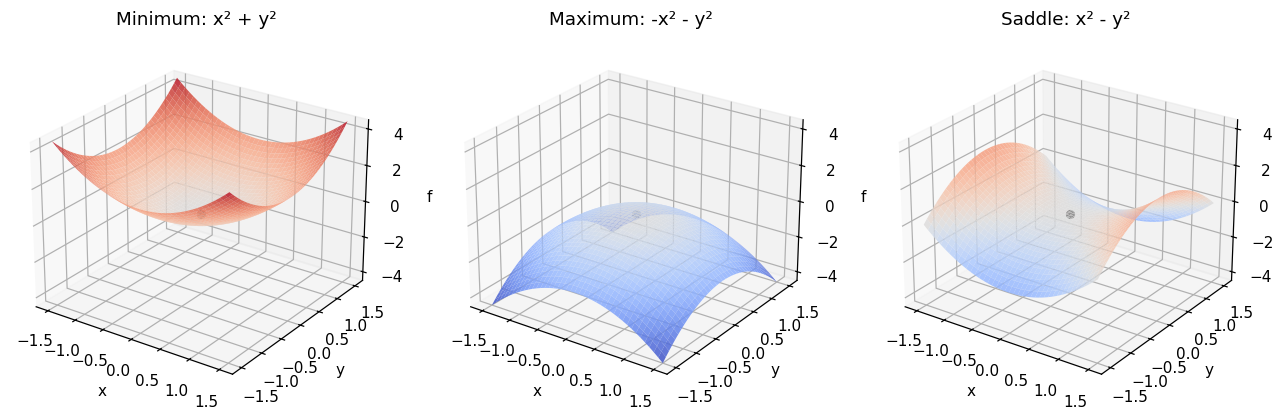

In [2]:
# 鞍点の例をみるのに、x^2 - y^2 のグラフを描いてみる。
import numpy as np
import matplotlib.pyplot as plt

grid = np.linspace(-1.5, 1.5, 81)
sx, sy = np.meshgrid(grid, grid)
fig = plt.figure(figsize=(12, 3.8))
examples = [(sx**2 + sy**2, "Minimum: x² + y²"),
            (-sx**2 - sy**2, "Maximum: -x² - y²"),
            (sx**2 - sy**2, "Saddle: x² - y²")]
for index, (values, title) in enumerate(examples, start=1):
    ax = fig.add_subplot(1, 3, index, projection="3d")
    ax.plot_surface(sx, sy, values, cmap="coolwarm", alpha=0.85,
                    vmin=-4.5, vmax=4.5)
    ax.scatter([0], [0], [0], color="black", s=25)
    ax.set(xlabel="x", ylabel="y", zlabel="f", title=title, zlim=(-4.5, 4.5))
    ax.view_init(elev=25, azim=-55)
fig.tight_layout()
plt.show()

## 計算例: 線形回帰の勾配とヘッセ行列

冒頭の線形回帰に戻り、ここまでの微分を実際に計算しよう。
$N\geq1$個のデータ$(x_i,y_i)$は固定し、パラメータ$\boldsymbol{\theta}=(a,b)^T$だけを変数とする。
目的関数と残差を

$$
f(a,b)=\frac1N\sum_{i=1}^N r_i^2,\qquad r_i=ax_i+b-y_i
$$

と書く。残差の符号は冒頭と逆だが、二乗するため目的関数は同じである。
$\partial r_i/\partial a=x_i$、$\partial r_i/\partial b=1$なので、連鎖律より

$$
\frac{\partial f}{\partial a}=\frac2N\sum_i r_i x_i,\qquad
\frac{\partial f}{\partial b}=\frac2N\sum_i r_i.
$$

したがって、勾配とヘッセ行列は

$$
\nabla_{\boldsymbol{\theta}}f
=\frac2N\begin{pmatrix}\sum_i r_i x_i\\\sum_i r_i\end{pmatrix},\qquad
\boldsymbol{H}_f
=\frac2N\begin{pmatrix}\sum_i x_i^2&\sum_i x_i\\\sum_i x_i&N\end{pmatrix}
$$

となる。このヘッセ行列はパラメータ$(a,b)$に依存しない。
任意の変位$\Delta\boldsymbol{\theta}=(\Delta a,\Delta b)^T$に対して、

$$
\Delta\boldsymbol{\theta}^T\boldsymbol{H}_f\Delta\boldsymbol{\theta}
=\frac2N\sum_i(x_i\Delta a+\Delta b)^2\geq0
$$

なので、$\boldsymbol{H}_f$は半正定値である。
さらに、この目的関数は二次関数なので二次のテイラー展開の誤差は厳密に0となる。
停留点$\boldsymbol{\theta}_*$では、任意の変位に対して

$$
f(\boldsymbol{\theta}_*+\Delta\boldsymbol{\theta})-f(\boldsymbol{\theta}_*)
=\frac12\Delta\boldsymbol{\theta}^T\boldsymbol{H}_f\Delta\boldsymbol{\theta}\geq0
$$

である。この不等式は小さな変位だけでなく、任意の$\Delta\boldsymbol{\theta}$に対して成り立つ。
つまり、どのパラメータと比較しても$f(\boldsymbol{\theta}_*)$より小さい値にはならないので、この停留点は**大域的な最小点**である。

`````{admonition} 注意: 一般の関数では局所的な情報と大域的な最適性を区別する
:class: attention

一般の関数では、上の結論をそのまま使うことはできない。

- 勾配がゼロであることは停留点の条件であり、最小点であることを保証しない。最大点や鞍点の場合もある。
- ２階連続微分可能な関数の停留点でヘッセ行列が正定値なら、狭義の**局所最小点**とはいえる。しかし、離れた場所にさらに小さい関数値がある可能性は残る。
- その点のヘッセ行列が半正定値でゼロ固有値を含む場合は、局所最小点かどうかさえ二次の情報だけでは判定できない。

例えば$f(x)=x^2-x^4$では、$f'(0)=0$かつ$f''(0)=2>0$なので原点は局所最小点である。
しかし$f(2)=-12<f(0)=0$であり、大域的な最小点ではない。

一般の関数の二次のテイラー展開は、その点の近くで成り立つ近似である。
今回の線形回帰では、目的関数が二次関数なので展開の誤差が厳密に0となり、しかも二次の項が任意の変位について非負になる。
この二つの性質によって、大域的な最小点であることまで確認できる。

`````

### 解が一意に決まる条件

$x_i$に少なくとも二つの異なる値があれば、
すべての$i$で$x_i\Delta a+\Delta b=0$となるのは$\Delta a=\Delta b=0$の場合だけである。
このときヘッセ行列は正定値であり、最小点は一意に決まる。

一方、すべての入力が$x_i=c$なら、予測値はすべて$ac+b$となり、
データから区別できるのはこの組合せだけである。
$\bar y=\frac1N\sum_i y_i$とすると、

$$
f(a,b)=(ac+b-\bar y)^2+\frac1N\sum_i(y_i-\bar y)^2
$$

なので、$ac+b=\bar y$を満たすすべての$(a,b)$が最小点となる。
変位$(\Delta a,\Delta b)=(t,-ct)$に沿って予測値も目的関数も変わらず、この方向がヘッセ行列のゼロ固有値に対応する。

計画行列$\mathbf{X}$の各行を$(x_i,1)$とすれば、上の結果は
$\nabla f=\frac2N\mathbf{X}^T(\mathbf{X}\boldsymbol{\theta}-\mathbf{y})$、
$\boldsymbol{H}_f=\frac2N\mathbf{X}^T\mathbf{X}$とまとめられる。
解の行列表現と一般の基底関数への拡張は[線形回帰の章](Chapter_linear_regression.ipynb)で扱う。

### 中心差分による勾配の検算

手計算やコードで求めた勾配は、各パラメータを少しだけ変えて検算できる。
$\mathbf{e}_j$を$j$番目の成分だけが1の単位ベクトルとすると、中心差分は

$$
\frac{\partial f}{\partial\theta_j}(\boldsymbol{\theta})
\approx\frac{f(\boldsymbol{\theta}+h\mathbf{e}_j)-f(\boldsymbol{\theta}-h\mathbf{e}_j)}{2h}
$$

である。十分滑らかな一般の関数では打切り誤差は$O(h^2)$だが、$h$を小さくしすぎると丸め誤差の影響が大きくなる。
今回の二次関数では打切り誤差は厳密に0なので、数値的なずれは主に浮動小数点演算によるものである。
次のコードで解析的な勾配との一致と、入力がすべて同じ場合のゼロ固有値を確認しよう。

In [3]:
import numpy as np

x_data = np.array([-1.0, 0.0, 1.0, 2.0])
y_data = np.array([-0.8, 0.9, 3.2, 4.7])
design = np.column_stack([x_data, np.ones_like(x_data)])
theta = np.array([0.4, -0.2])  # (a, b)


def regression_loss(parameters):
    residual = design @ parameters - y_data
    return np.mean(residual**2)


residual = design @ theta - y_data
analytic_gradient = 2 * design.T @ residual / len(x_data)
hessian = 2 * design.T @ design / len(x_data)
h = 1e-5
finite_difference = np.array([
    (regression_loss(theta + h * direction)
     - regression_loss(theta - h * direction)) / (2 * h)
    for direction in np.eye(len(theta))
])

print("Analytic gradient:", analytic_gradient)
print("Central difference:", finite_difference)
print("Maximum absolute error:", np.max(np.abs(analytic_gradient - finite_difference)))
print("Gradients agree:", np.allclose(analytic_gradient, finite_difference,
                                     rtol=1e-7, atol=1e-9))
print("Hessian eigenvalues:", np.linalg.eigvalsh(hessian))

# 入力がすべて c = 2 の場合は (a, b) と (a + t, b - 2t) を区別できない。
constant_design = np.column_stack([np.full(len(x_data), 2.0), np.ones(len(x_data))])
constant_hessian = 2 * constant_design.T @ constant_design / len(x_data)
null_direction = np.array([1.0, -2.0])
print("Hessian eigenvalues (constant inputs):", np.linalg.eigvalsh(constant_hessian))
print("Predictions unchanged along (1, -2):",
      np.allclose(constant_design @ theta,
                  constant_design @ (theta + null_direction)))

Analytic gradient: [-5.7 -4. ]
Central difference: [-5.7 -4. ]
Maximum absolute error: 1.8204548979383617e-11
Gradients agree: True
Hessian eigenvalues: [1.38196601 3.61803399]
Hessian eigenvalues (constant inputs): [ 0. 10.]
Predictions unchanged along (1, -2): True


`````{admonition} 問題
:class: attention

1. 上の中心差分で$h$を$10^{-2},10^{-5},10^{-8},10^{-11}$に変え、勾配の誤差を比較せよ。今回の目的関数が二次関数であることに注意し、$h$を小さくすれば常に誤差も小さくなるか考察せよ。
2. $f(x,y)=x^2+2y^2$の点$(1,1)$において、$\mathbf{v}=(1,1)^T/\sqrt2$方向の方向微分を求めよ。また、単位長さあたりの減少率が最も大きい方向を求めよ。
3. $f(x,y)=x^2+xy+2y^2$について、点$(1,0)$で二次までのテイラー展開を求め、元の関数と厳密に一致することを確認せよ。

`````

## 条件つき最適化

機械学習モデルのような特定のモデルでデータの説明を試みる場合、モデルのパラメータや変数に対して制約条件が課されることがある。
こうした場合、制約条件を満たしつつ目的関数を最小化する必要がある。
そのような問題を条件つき最適化問題と呼ぶが、中でも非常によく用いられる手法が **ラグランジュ未定乗数法 (Lagrange multipliers)** である。

$$
\begin{align*}
\text{minimize} \quad & f(\mathbf{x}) \\
\text{subject to} \quad & g_i(\mathbf{x}) = 0, \quad i = 1, \ldots, m
\end{align*}
$$  

上の式の意味するところは、$m$個の制約条件$g_i(\mathbf{x}) = 0$を満たしつつ、目的関数$f(\mathbf{x})$を最小化せよ、ということである。
制約のない微分可能な関数では、定義域の内部の極値候補を$\nabla f(\mathbf{x})=0$から探せるが、それだけで最小点と判定できるわけではない。
等式制約がある場合は、ラグランジュ関数を導入して次の条件を考える。

$$
\begin{align*}
\mathcal{L}(\mathbf{x}, \boldsymbol{\lambda}) &= f(\mathbf{x}) + \sum_{i=1}^m \lambda_i g_i(\mathbf{x}) \\
\nabla_{\mathbf{x}} \mathcal{L}(\mathbf{x}, \boldsymbol{\lambda}) &= 0 \\
\nabla_{\boldsymbol{\lambda}} \mathcal{L}(\mathbf{x}, \boldsymbol{\lambda}) &= 0
\end{align*}
$$  

$f,g_1,\ldots,g_m$が考える点の近傍で連続微分可能であり、制約を満たす局所最適点$\mathbf{x}_*$で
制約勾配$\nabla g_1(\mathbf{x}_*),\ldots,\nabla g_m(\mathbf{x}_*)$が一次独立ならば、
上の条件を満たす乗数$\boldsymbol{\lambda}$が存在する。
これは局所最適点の**必要条件**であり、方程式の解が最小点であることを保証する十分条件ではない。
得られた候補について、制約上での関数値の比較や二次の変化などを調べ、最適性を確認する必要がある。
制約勾配が一次独立でない点や、別途定義域の境界がある場合の境界上の候補は、別に調べる必要がある。

幾何学的には、制約を保つ接線方向$\mathbf{v}$は$\nabla g_i^T\mathbf{v}=0$を満たす。
正則な制約上の局所最適点ではその方向の変化率$\nabla f^T\mathbf{v}$も0となるため、
目的関数の勾配は制約勾配の線形結合$\nabla f=-\sum_i\lambda_i\nabla g_i$で表される。
制約が一つなら、目的関数と制約の勾配が平行になる（目的関数の勾配がゼロの場合も含む）。

**練習問題**

> 制約条件$x+y=1$のもとで、関数$f(x,y) = x^2 + y^2$を最小化せよ。

$$
\begin{align*}
\mathcal{L}(x,y,\lambda) &= f(x,y) + \lambda (g(x,y)) \\
&= x^2 + y^2 + \lambda (x+y-1)
\end{align*}
$$

$$
\begin{align*}
\nabla_{(x,y,\lambda)} \mathcal{L}(x,y,\lambda) &= 
\begin{bmatrix}
2x + \lambda \\
2y + \lambda \\
x + y - 1
\end{bmatrix}   = 0
\end{align*}
$$  

この方程式から、候補$x=y=\frac12$と$\lambda=-1$を得る。
ここで制約勾配は$(1,1)^T\ne\mathbf0$なので、上の必要条件を適用できる。
最小点であることは、制約$y=1-x$を目的関数に代入して

$$
f(x,1-x)=x^2+(1-x)^2=2\left(x-\frac12\right)^2+\frac12\geq\frac12
$$

と書けば確認できる。等号は$x=y=\frac12$のときだけ成り立つので、これが制約上の一意な大域的最小点である。

問題の式をみると、$f(x,y)$は$x,y$の二乗和でありこれを$r^2$とおけば、原点を中心とする半径$r$の円上の点を表せる。
一方で、制約条件$x+y=1$は、$x$軸との交点$(1,0)$と$y$軸との交点$(0,1)$を通る直線を表す。
したがって今の問題は、原点を中心とする半径$r$の円が、直線$x+y=1$に接するような$r$と接点を求める問題である事がわかる。

簡単な問題の場合は、こうした幾何学的な解釈を行うことで、最適解を直感的に理解できることがあるが、より複雑な問題の場合は、ラグランジュ未定乗数法のような一般的な手法を用いるのが良いだろう。


`````{admonition} 問題
:class: attention

表面積が一定である直方体のうち、体積が最大となるものが立方体であることを示せ。

`````



## 学習の振り返りのためのチェックリスト

▢ 　一変数関数の微分とテイラー展開の基本を説明できる  
▢ 　偏微分・勾配の意味と、勾配降下法との関係を説明できる  
▢ 　ヤコビ行列と連鎖律を用いて、合成関数を微分できる  
▢ 　多変数のテイラー展開とヘッセ行列を用いた極値判定を説明できる  
▢ 　ラグランジュ未定乗数法で条件つき最適化の候補を求め、最適性を確認できる
